In [21]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import median_abs_deviation as mad

Useful function for the plot

In [22]:
def display_band( X, par,epsi=0.001,col='k'):
    x1 = np.min(X[0, :])
    x2 = np.max(X[0, :])
    y1 = np.min(X[1, :])
    y2 = np.max(X[1, :])

    # extend the line for the k# of its lenght 
    k = 0.01
    dx = x2-x1
    dy = y2-y1
    l = np.sqrt(dx**2+dy**2)
    x1 = x1 - k*l
    x2 = x2 + k*l
    y1 = y1 - k*l
    y2 = y2 + k*l
    
    if np.abs(par[1])<2e-2:
        # disp('vertical line')
        a = np.vstack([-(par[1]*y1 + par[2])/par[0], y1])
        b = np.vstack([-(par[1]*y2 + par[2])/par[0], y2])
    else:
        a = np.vstack([x1, -(par[0]*x1 + par[2])/par[1]])
        b = np.vstack([x2, -(par[0]*x2 + par[2])/par[1]])

    if np.abs(par[0])<1e-5:
        v = np.array([0,1]) 
    else:   
        v = np.array([1, par[1]/par[0]])# direction perpendicular to the line;

    v = v / np.sqrt(np.sum(v**2))
    # corners of the bands
    v = v[:, np.newaxis]
    a1 = a - epsi * v
    a2 = a + epsi * v
    b1 = b - epsi * v
    b2 = b + epsi * v

    px = np.array([a1[0], b1[0], b2[0], a2[0]]).squeeze()
    py = np.array([a1[1], b1[1], b2[1], a2[1]]).squeeze()
    plt.tricontourf(px,py,np.ones_like(px), colors=col,alpha=0.5)
    plt.gca().set_aspect('equal')

Function that computes the residual between points and a line

In [23]:
def res_line(X, M):
    if len(M.shape) > 1:
        num_lines = M.shape[1]
    else:
        num_lines = 1

    if num_lines == 1:
        d = np.abs(M[0] * X[0, :] + M[1] * X[1, :] + M[2])
    else:
        n = X.shape[1]
        d = np.zeros((n, num_lines))
        for i in range(num_lines):
            d[:, i] = np.abs(M[0, i] * X[0, :] + M[1, i] * X[1, :] + M[2, i])

Implement the following function, that computes the solution of the overdetermined system

$$\underset{A}{\text{argmin}} \| A\mathbf x - \mathbf y\|_2^2$$

via OLS and DLT

The input $P=[[x_1, y_1], \dots,[x_N,y_N]]$ collects the points where the line $y = mx+q$ should pass through

In [24]:
def fit_line_ols(P):
    # design matrix
    A = np.column_stack((P[:, 0], np.ones_like(P[:, 0])))
    # vector of responses
    y = P[:, 1]

    # straight line coefficient
    theta = np.linalg.inv(A.T @ A) @ A.T @ y

    residuals = y - A @ theta
    residual_error = np.sum(residuals ** 2)
    
    return theta, residuals, residual_error

In [25]:
def fit_line_dlt(P):
    # design matrix
    A = np.column_stack((P[:, 0], P[:, 1], np.ones_like(P[:, 0])))
    
    # SVD
    _, _, VT = np.linalg.svd(A, full_matrices=True)
    
    theta = VT.T[:, -1]
    
    residuals = A @ theta   
    residual_error = np.sum(residuals ** 2)
    
    return theta, residuals, residual_error

Robust Fitting Methods
----------------------
Implements the following methods:

In [26]:
def simpleRANSAC(X, eps, cardmss=2):
    # number of samples in the dataset
    n = X.shape[1] 
    
    # desired probability of success
    alpha = 0.99 

    # pessimistic estimate of inliers fraction
    f = 0.5
    # probability of being outlier
    e = 1 - f

    # set maximum number of iterations
    maxIterations = int(np.ceil(np.log(1 - alpha) / np.log(1 - (1 - e) ** cardmss)))

    # set maximum consensus reached
    maxscore = -np.inf
    
    for k in range(maxIterations):
        # generate cardmss random indices in the range 0 ... (N-1)
        mss_k = np.random.choice(n, size=cardmss, replace=False)
        
        # fit model to this minimal sample set
        theta_k, _, _ = fit_line_dlt(X[:, mss_k].T)

        # evaluate distances between points and model
        sqres = (theta_k[0] * X[0, :] + theta_k[1] * X[1, :] + theta_k[2])**2 / (theta_k[0]**2 + theta_k[1]**2)

        # identify inliers: consensus set
        inliers = np.where(sqres < eps**2)[0]

        # assess consensus (the number of inliers)
        score = len(inliers)
        
        # replace maxscore, bestinliers and bestmodel if needed
        if score > maxscore:
            maxscore = score
            bestinliers = inliers
            bestmodel = theta_k

    return bestmodel, bestinliers

In [ ]:
def simpleMSAC(X, eps, cardmss=2):
    # number of samples in the dataset
    n = X.shape[1]
    
    # desired probability of success
    alpha = 0.99
    
    # pessimistic estimate of inliers fraction
    f = 0.5
    # probability of being outlier
    e = 1 - f

    # set maximum number of iterations
    maxIterations = int(np.ceil(np.log(1 - alpha) / np.log(1 - (1 - e) ** cardmss)))

    # set maximum consensus reached
    mincost = np.inf

    for k in range(maxIterations):
        # generate cardmss random indices in the range 0 ... (N-1)
        mss_k = np.random.choice(n, size=cardmss, replace=False)

        # fit model to this minimal sample set
        theta_k = fit_line_dlt(X[:, mss_k].T)[0]

        # evaluate distances between points and model
        sqres = (theta_k[0] * X[0, :] + theta_k[1] * X[1, :] + theta_k[2])**2 / (theta_k[0]**2 + theta_k[1]**2)

        # identify inliers: consensus set
        inliers = np.where(sqres <= eps**2)[0]

        # compute MSAC score
        cost = 0
        # foreach inlier, add the squared residual to the cost
        for i in inliers:
            cost += sqres[i]
        # foreach outlier, add eps^2 to the cost
        cost += (n - len(inliers)) * eps**2

        # replace mincost, bestinliers and bestmodel if needed
        if cost < mincost:
            mincost = cost
            bestinliers = inliers
            bestmodel = theta_k

    return bestmodel, bestinliers

In [28]:
def simpleLMEDS(X, cardmss=2):
    n = X.shape[1]
    
    # desired probability of success
    alpha = 0.99
    
    # pessimistic estimate of inliers fraction
    f = 0.5
    # probability of being outlier
    e = 1 - f

    # set maximum number of iterations
    maxIterations = int(np.ceil(np.log(1 - alpha) / np.log(1 - (1 - e) ** cardmss)))

    # set maximum consensus reached
    mincost = np.inf

    for k in range(maxIterations):
        # generate cardmss random indicies in the range 0 ... (N-1)
        mss_k = np.random.choice(n, size=cardmss, replace=False)

        # fit model to this minimal sample set.
        theta_k = fit_line_dlt(X[:, mss_k].T)[0]

        # evaluate distances between points and model
        sqres = (theta_k[0] * X[0, :] + theta_k[1] * X[1, :] + theta_k[2])**2 / (theta_k[0]**2 + theta_k[1]**2)

        # compute LMS score
        cost = np.median(sqres)

        # define inliner threshold (does make sense only when the model provides a good fit)
        # compute the standard deviation of distances (you can use MAD)
        scale = mad(sqres, scale='normal')

        # instead of 3-sigma rule, we do 2.5-sigma rule. sqres is already squares
        inliers = np.where(sqres < 2.5*scale)[0]

        # replace mincost, bestinliers and bestmodel if needed
        if cost < mincost:
            mincost = cost
            bestinliers = inliers
            bestmodel = theta_k

    return bestmodel, bestinliers

Fitting over noisy data
-----------------------
Set the parameters and generate the dataset

In [29]:
# minimum number of points required to fit a model
cardmss = 2

# plotting params
BAND_WIDTH = 0.05
BAND_COLOR = 'b'

# create noisy dataset
x = np.linspace(0,1,100)
y = 1.5 * x + 1
X = np.vstack((x, y))
sigma = 0.01
X = X + sigma * np.random.normal(size=X.shape)

Least square fit to noisy data

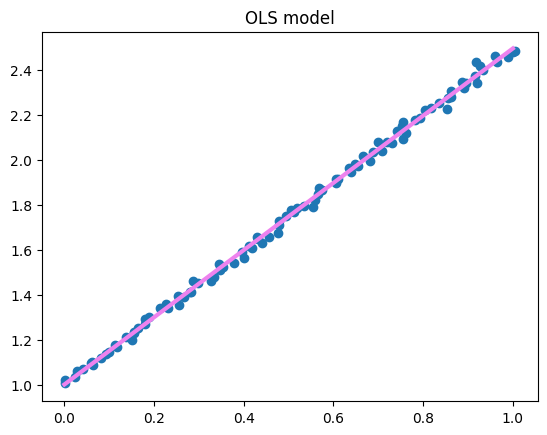

In [30]:
model_OLS = fit_line_ols(X.T)[0]

plt.figure()
plt.scatter(X[0,:], X[1,:])
plt.plot([0, 1], [model_OLS[1], model_OLS[0] + model_OLS[1]], 'violet', linewidth=3)
plt.title('OLS model')
plt.show()

Least square fit via DLT (different model parametrization)

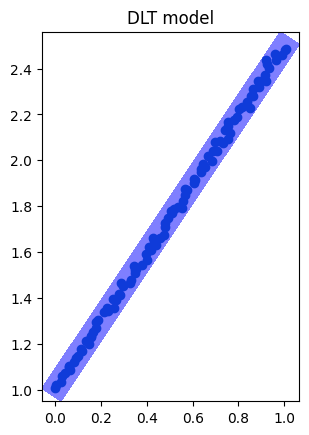

In [31]:
model_DLT = fit_line_dlt(X.T)[0]

plt.figure()
plt.scatter(X[0,:], X[1,:])
display_band(X, model_DLT, BAND_WIDTH , BAND_COLOR)
plt.title('DLT model')
plt.show()

Add a single outlier to the data, obtaining a new dataset $X_{out}$

In [32]:
X_out = np.hstack([X, np.array([[1.5], [1]])])

Least square fit to noisy data with a single outlier

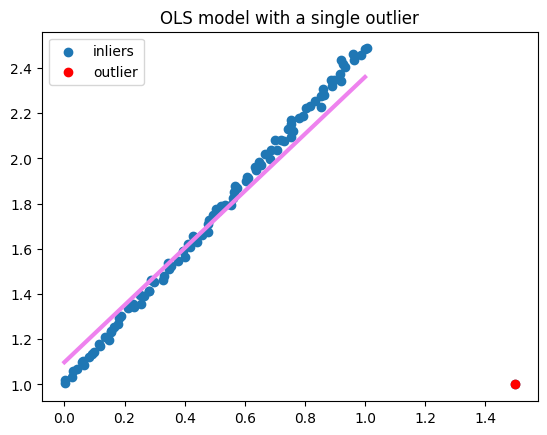

In [33]:
model_OLS = fit_line_ols(X_out.T)[0]

plt.figure()
plt.scatter(X_out[0,:], X_out[1,:], c='C0', label='inliers')
plt.scatter(X_out[0, -1], X_out[1, -1], c='r', label='outlier')
plt.plot([0, 1], [model_OLS[1], model_OLS[0] + model_OLS[1]], 'violet', linewidth=3)
plt.title('OLS model with a single outlier')
plt.legend(loc='upper left')
plt.show()

Least square fit via DLT to noisy data with a single outlier

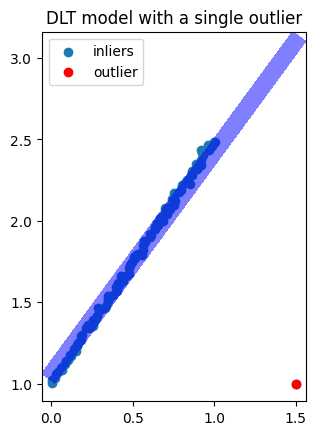

In [34]:
model_DLT = fit_line_dlt(X_out.T)[0]

plt.figure()
# color the outliers in red (last point is the outlier)
plt.scatter(X_out[0,:], X_out[1,:], c='C0', label='inliers')
plt.scatter(X_out[0, -1], X_out[1, -1], c='r', label='outlier')
display_band(X_out, model_DLT, BAND_WIDTH , BAND_COLOR)
plt.title('DLT model with a single outlier')
plt.legend(loc='upper left')
plt.show()

Add many outliers to the noisy data

In [35]:
n_out = 50
X_outs = np.hstack([X, [np.random.uniform(0, 1, n_out), np.random.uniform(1, 2.5, n_out)]])

Least square fit

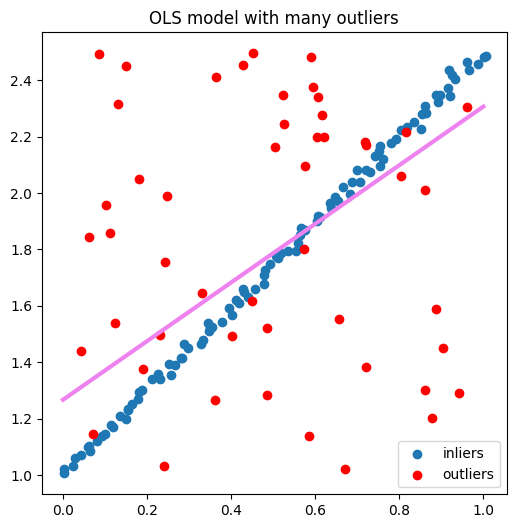

In [36]:
model_OLS = fit_line_ols(X_outs.T)[0]

plt.figure(figsize=(6, 6))
# original noisy points (inliers) vs added outliers
n_in = X_outs.shape[1] - n_out
plt.scatter(X_outs[0, :n_in], X_outs[1, :n_in], c='C0', label='inliers')
plt.scatter(X_outs[0, n_in:], X_outs[1, n_in:], c='r', label='outliers')
plt.plot([0, 1], [model_OLS[1], model_OLS[0] + model_OLS[1]], 'violet', linewidth=3)
plt.title('OLS model with many outliers')
plt.legend()
plt.show()

Least square via DLT

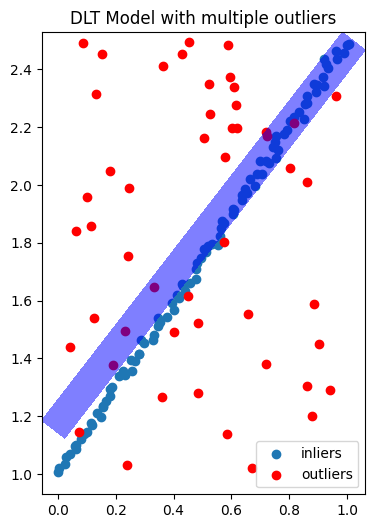

In [37]:
model_DLT = fit_line_dlt(X_outs.T)[0]

plt.figure(figsize=(6, 6))
# original noisy points (inliers) vs added outliers
plt.scatter(X_outs[0, :n_in], X_outs[1, :n_in], c='C0', label='inliers')
plt.scatter(X_outs[0, n_in:], X_outs[1, n_in:], c='r', label='outliers')
display_band(X_outs, model_DLT, BAND_WIDTH , BAND_COLOR)
plt.title('DLT Model with multiple outliers')
plt.legend()
plt.show()

Robust Fitting methods
----------------------
Use Ransac, M-Sac and L-Meds to perform fitting on data with many outliers

Ransac:


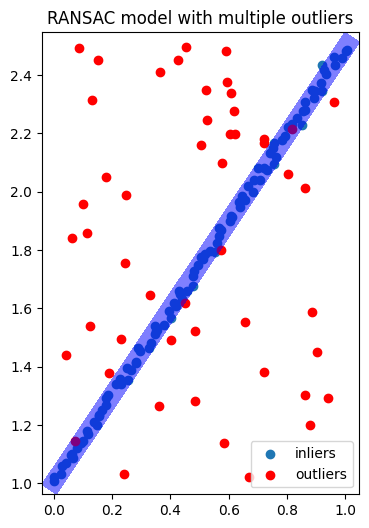

In [38]:
# define inlier threshold
epsi = 3 * sigma

# invoke simpleRANSAC
bestmodel, bestinliers = simpleRANSAC(X_outs, epsi)

# refine model estimates
refinedModel = fit_line_dlt(X_outs[:, bestinliers].T)[0]

plt.figure(figsize=(6, 6))
# original noisy points (inliers) vs added outliers
plt.scatter(X_outs[0, :n_in], X_outs[1, :n_in], c='C0', label='inliers')
plt.scatter(X_outs[0, n_in:], X_outs[1, n_in:], c='r', label='outliers')
display_band(X_outs, refinedModel, epsi, BAND_COLOR)
plt.title('RANSAC model with multiple outliers')
plt.legend()
plt.show()

M-Sac:

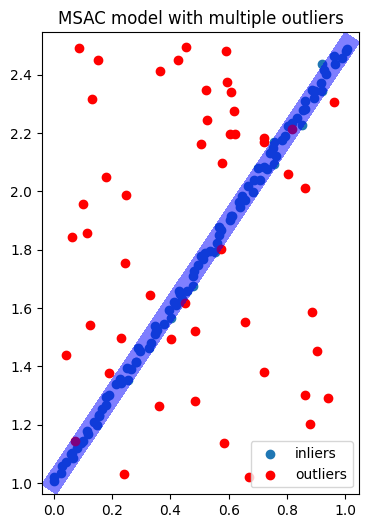

In [39]:
bestmodel, bestinliers = simpleMSAC(X_outs, epsi)

# refine model estimates
refinedModel = fit_line_dlt(X_outs[:, bestinliers].T)[0]

plt.figure(figsize=(6, 6))
# original noisy points (inliers) vs added outliers
plt.scatter(X_outs[0, :n_in], X_outs[1, :n_in], c='C0', label='inliers')
plt.scatter(X_outs[0, n_in:], X_outs[1, n_in:], c='r', label='outliers')
display_band(X_outs, refinedModel, epsi, BAND_COLOR)
plt.title('MSAC model with multiple outliers')
plt.legend()
plt.show()

L-Meds:

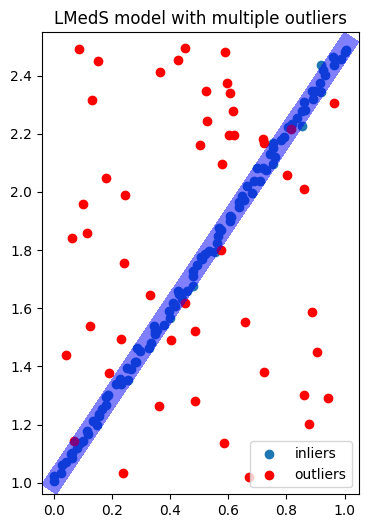

In [40]:
# invoke simpleLMEDS
bestmodel, bestinliers = simpleLMEDS(X_outs, cardmss=2)

# refine model estimates
refinedModel = fit_line_dlt(X_outs[:, bestinliers].T)[0]

plt.figure(figsize=(6, 6))
# original noisy points (inliers) vs added outliers
plt.scatter(X_outs[0, :n_in], X_outs[1, :n_in], c='C0', label='inliers')
plt.scatter(X_outs[0, n_in:], X_outs[1, n_in:], c='r', label='outliers')
display_band(X_outs, refinedModel, epsi, BAND_COLOR)
plt.title('LMedS model with multiple outliers')
plt.legend()
plt.show()